# Notebook 04 — Member Features, Master Join & Validation

**Corrections vs original prompt:**
- Column ID is `msno` (not `customer_id`)
- Members file is `members_v3.csv` (not `members.csv`)
- Label file is `train_v2.csv` (March 2017, 970,960 customers, 8.99% churn)
- `gender` values are `male`/`female`/NaN only — no `M`/`F` codes
- 67.1% of `bd` (birthdates) are invalid (0 or junk) → age null for those
- 115,801 customers (11.9%) have no log data → zero-filled; `days_since_last_log` set to **820** (max data span) not 0, since 0 would falsely imply "logged today"

## Section 1 — Member Feature Engineering

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

ROOT    = Path("..").resolve()
DATA    = ROOT / "data"
OUTPUTS = ROOT / "outputs"
OUTPUTS.mkdir(exist_ok=True)

SNAPSHOT_INT  = 20170331          # YYYYMMDD integer for all date arithmetic
SNAPSHOT_DATE = pd.Timestamp("2017-03-31")
LOG_MAX_DAYS  = 820               # max days_since_last_log in the dataset

print(f"Root: {ROOT}")

Root: C:\Users\h11la\OneDrive\Documents\00 Portfolio\Customer Analytics ML Pipeline\retail-clv-churn-prediction


In [2]:
members_raw = pd.read_csv(DATA / "members_v3.csv")
print(f"members_v3.csv: {members_raw.shape[0]:,} rows  x  {members_raw.shape[1]} cols")

members = members_raw.copy()

# ── age ────────────────────────────────────────────────────────────────────
# DATA DISCOVERY: bd stores age directly (int, e.g. 0/25/30), NOT a YYYYMMDD date.
# The formula (20170331 - bd) / 10000 from the prompt would give ~2017 for every row
# → every value fails the > 100 filter → 100% NaN. Fix: use bd directly as age.
members["age"] = members["bd"].where(
    (members["bd"] >= 5) & (members["bd"] <= 100),
    other=np.nan
)

valid_ages = members["age"].notna().sum()
print(f"\nage: {valid_ages:,} valid  ({valid_ages/len(members)*100:.1f}%)  "
      f"| {members['age'].isna().sum():,} NaN  ({members['age'].isna().sum()/len(members)*100:.1f}%)")
print(f"  mean={members['age'].mean():.1f}  median={members['age'].median():.1f}  "
      f"min={members['age'].min():.0f}  max={members['age'].max():.0f}")

# ── membership_tenure ──────────────────────────────────────────────────────
# registration_init_time stored as YYYYMMDD integer — this formula is correct
members["reg_date"] = pd.to_datetime(
    members["registration_init_time"].astype(str), format="%Y%m%d", errors="coerce"
)
members["membership_tenure"] = (SNAPSHOT_DATE - members["reg_date"]).dt.days
members.loc[members["membership_tenure"] < 0, "membership_tenure"] = np.nan
print(f"\nmembership_tenure: "
      f"mean={members['membership_tenure'].mean():.0f}d  "
      f"median={members['membership_tenure'].median():.0f}d  "
      f"NaN={members['membership_tenure'].isna().sum()}")

# ── city — frequency label encode ─────────────────────────────────────────
city_freq = members["city"].value_counts()
city_rank = {city: rank+1 for rank, city in enumerate(city_freq.index)}
members["city_freq_rank"] = members["city"].map(city_rank)
print(f"\ncity: {members['city'].nunique()} unique values -> frequency-rank encoded")
print(f"  Top 5: {dict(list(city_freq.items())[:5])}")

# ── gender one-hot ─────────────────────────────────────────────────────────
# Actual values in members_v3: 'male', 'female', NaN  (no 'M'/'F' codes)
members["gender_male"]    = (members["gender"] == "male").astype(int)
members["gender_female"]  = (members["gender"] == "female").astype(int)
members["gender_unknown"] = members["gender"].isna().astype(int)
print(f"\ngender one-hot distribution:")
for col in ["gender_male","gender_female","gender_unknown"]:
    print(f"  {col}: {members[col].sum():,}  ({members[col].mean()*100:.1f}%)")

# ── registered_via one-hot ─────────────────────────────────────────────────
top5_via = members["registered_via"].value_counts().head(5).index.tolist()
print(f"\nregistered_via top 5 values: {top5_via}")
for v in top5_via:
    members[f"reg_via_{v}"] = (members["registered_via"] == v).astype(int)
members["reg_via_other"] = (~members["registered_via"].isin(top5_via)).astype(int)

keep_cols = (
    ["msno", "city_freq_rank", "age", "membership_tenure",
     "gender_male", "gender_female", "gender_unknown"]
    + [f"reg_via_{v}" for v in top5_via]
    + ["reg_via_other", "registration_init_time"]
)
members_eng = members[keep_cols].copy()
print(f"\nEngineered members shape: {members_eng.shape}")
print(f"Columns: {list(members_eng.columns)}")

members_v3.csv: 6,769,473 rows  x  6 cols



age: 2,223,342 valid  (32.8%)  | 4,546,131 NaN  (67.2%)


  mean=29.5  median=27.0  min=5  max=100



membership_tenure: mean=845d  median=542d  NaN=55094

city: 21 unique values -> frequency-rank encoded
  Top 5: {1: 4804326, 5: 385069, 13: 320978, 4: 246848, 22: 210407}



gender one-hot distribution:
  gender_male: 1,195,355  (17.7%)
  gender_female: 1,144,613  (16.9%)
  gender_unknown: 4,429,505  (65.4%)

registered_via top 5 values: [4, 3, 9, 7, 11]



Engineered members shape: (6769473, 14)
Columns: ['msno', 'city_freq_rank', 'age', 'membership_tenure', 'gender_male', 'gender_female', 'gender_unknown', 'reg_via_4', 'reg_via_3', 'reg_via_9', 'reg_via_7', 'reg_via_11', 'reg_via_other', 'registration_init_time']


## Section 2 — Master Join

In [3]:
train_v2   = pd.read_csv(DATA / "train_v2.csv")
tx_feats   = pd.read_parquet(OUTPUTS / "transaction_features.parquet")
log_feats  = pd.read_parquet(OUTPUTS / "log_features.parquet")

print(f"train_v2        : {len(train_v2):,} rows")
print(f"tx_features     : {len(tx_feats):,} rows")
print(f"log_features    : {len(log_feats):,} rows")
print(f"members_eng     : {len(members_eng):,} rows")

# LEFT JOIN from train_v2 as base — every labelled customer must appear
df = (
    train_v2
    .merge(tx_feats,     on="msno", how="left")
    .merge(log_feats,    on="msno", how="left")
    .merge(members_eng,  on="msno", how="left")
)
print(f"\nAfter join: {df.shape[0]:,} rows x {df.shape[1]} cols")
print(f"Overall churn rate: {df['is_churn'].mean()*100:.2f}%")

# ── Null audit pre-fill ───────────────────────────────────────────────────
null_pre = df.isnull().sum()
null_pct  = (null_pre / len(df) * 100).round(1)
has_nulls = null_pre[null_pre > 0]
print(f"\nColumns with nulls before filling ({len(has_nulls)}):")
print(pd.DataFrame({"nulls": has_nulls, "null_%": null_pct[has_nulls.index]}).to_string())

train_v2        : 970,960 rows
tx_features     : 970,960 rows
log_features    : 855,159 rows
members_eng     : 6,769,473 rows



After join: 970,960 rows x 39 cols
Overall churn rate: 8.99%

Columns with nulls before filling (25):
                         nulls  null_%
discount_rate              451     0.0
total_secs              115801    11.9
avg_daily_secs          115801    11.9
max_daily_secs          115801    11.9
total_songs_played      115801    11.9
completion_rate         115801    11.9
skip_rate               115801    11.9
unique_songs_ratio      115801    11.9
active_days             115801    11.9
last_log_date           115801    11.9
first_log_date          115801    11.9
days_since_last_log     115801    11.9
city_freq_rank          109993    11.3
age                     584294    60.2
membership_tenure       109994    11.3
gender_male             109993    11.3
gender_female           109993    11.3
gender_unknown          109993    11.3
reg_via_4               109993    11.3
reg_via_3               109993    11.3
reg_via_9               109993    11.3
reg_via_7               109993    11.3


In [4]:
# ── Flag: customers with NO transactions ─────────────────────────────────
no_tx = df["n_transactions"].isna().sum()
print(f"Customers with NO transaction data: {no_tx:,}")
if no_tx > 0:
    print("  FLAG: unexpected missing transactions")
else:
    print("  OK: all labelled customers have transaction features")

# ── Fill: customers with NO log data → zero / max dormancy ───────────────
log_cols = [
    "total_secs", "avg_daily_secs", "max_daily_secs",
    "total_songs_played", "completion_rate", "skip_rate",
    "unique_songs_ratio", "active_days"
]
date_log_cols = ["last_log_date", "first_log_date"]
df[log_cols]      = df[log_cols].fillna(0)
df[date_log_cols] = df[date_log_cols].fillna(0)
# days_since_last_log=820 (max data span) for never-logged customers, not 0
df["days_since_last_log"] = df["days_since_last_log"].fillna(LOG_MAX_DAYS)

no_log = (df["active_days"] == 0).sum()
print(f"\nCustomers with NO log data (zero-filled): {no_log:,}  ({no_log/len(df)*100:.1f}%)")

# ── Fill: age → median ────────────────────────────────────────────────────
age_median = df["age"].median()
df["age"] = df["age"].fillna(age_median)
print(f"age median fill value: {age_median:.1f} years")

# ── Fill: membership_tenure nulls → median ───────────────────────────────
tenure_median = df["membership_tenure"].median()
df["membership_tenure"] = df["membership_tenure"].fillna(tenure_median)

# ── Fill: discount_rate (null when plan_list_price = 0) → 0 ──────────────
df["discount_rate"] = df["discount_rate"].fillna(0)

# ── Fill: 109,993 customers absent from members_v3 ────────────────────────
# city_freq_rank → mode (most common city rank = 1)
df["city_freq_rank"] = df["city_freq_rank"].fillna(1)
# gender → unknown  (0/0/1)
for gc in ["gender_male", "gender_female"]:
    df[gc] = df[gc].fillna(0).astype(int)
df["gender_unknown"] = df["gender_unknown"].fillna(1).astype(int)
# registered_via → 0 for all method columns (unknown)
for col in df.columns:
    if col.startswith("reg_via_"):
        df[col] = df[col].fillna(0).astype(int)

# ── Null audit post-fill ──────────────────────────────────────────────────
null_post = df.isnull().sum()
remaining = null_post[null_post > 0]
if len(remaining) == 0:
    print("\nNull audit PASSED — no remaining nulls")
else:
    print(f"\nWARNING: {len(remaining)} columns still have nulls:")
    print(remaining.to_string())

Customers with NO transaction data: 0
  OK: all labelled customers have transaction features

Customers with NO log data (zero-filled): 115,801  (11.9%)
age median fill value: 28.0 years



registration_init_time    109993


## Section 3 — Final Feature Set

In [5]:
# Drop raw date columns — not used as model features (raw YYYYMMDD integers)
DROP_COLS = [
    "first_transaction", "last_transaction", "last_expire_date",  # tx date integers
    "last_log_date", "first_log_date",                            # log date integers
    "registration_init_time",                                      # raw reg date
]
model_cols = [c for c in df.columns if c not in DROP_COLS + ["msno", "is_churn"]]

print(f"Total model features: {len(model_cols)}")
print()
for i, col in enumerate(model_cols, 1):
    print(f"  {i:2d}. {col}")

print(f"\nFull dataframe shape (incl. msno + is_churn): {df.shape}")

Total model features: 31

   1. total_paid
   2. avg_payment
   3. max_payment
   4. discount_rate
   5. n_transactions
   6. avg_plan_days
   7. auto_renew_rate
   8. cancel_rate
   9. days_as_member
  10. n_payment_methods
  11. total_secs
  12. avg_daily_secs
  13. max_daily_secs
  14. total_songs_played
  15. completion_rate
  16. skip_rate
  17. unique_songs_ratio
  18. active_days
  19. days_since_last_log
  20. city_freq_rank
  21. age
  22. membership_tenure
  23. gender_male
  24. gender_female
  25. gender_unknown
  26. reg_via_4
  27. reg_via_3
  28. reg_via_9
  29. reg_via_7
  30. reg_via_11
  31. reg_via_other

Full dataframe shape (incl. msno + is_churn): (970960, 39)


## Section 4 — Churn Rate Analysis

Overall churn rate: 8.99%  (expected 8-12% for KKBox)


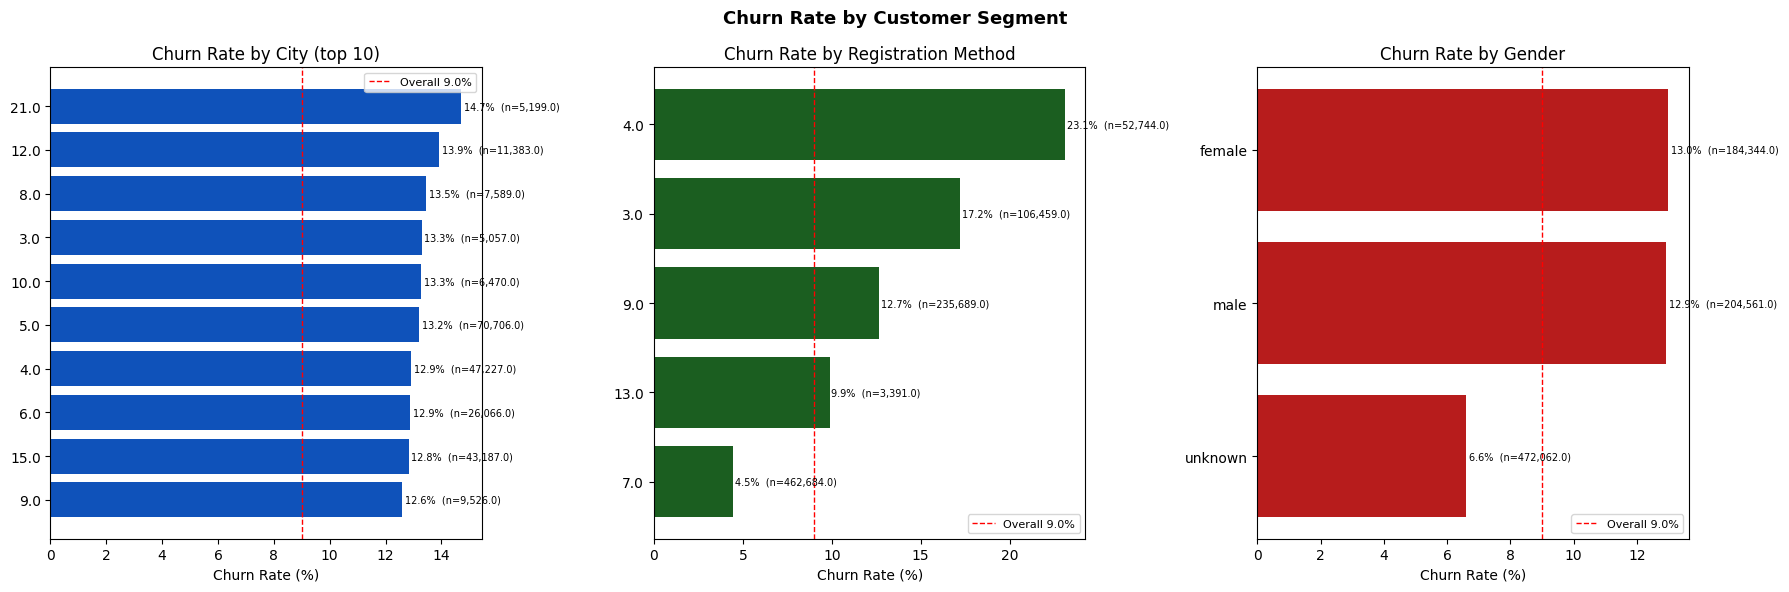

Saved: outputs/04_churn_rate_analysis.png


In [6]:
overall_churn = df["is_churn"].mean() * 100
print(f"Overall churn rate: {overall_churn:.2f}%  (expected 8-12% for KKBox)")

# Attach original city and registered_via for readable labels
df_analysis = df.copy()
df_analysis["city_raw"]    = members_raw.set_index("msno")["city"].reindex(df["msno"]).values
df_analysis["reg_via_raw"] = members_raw.set_index("msno")["registered_via"].reindex(df["msno"]).values
df_analysis["gender_raw"]  = members_raw.set_index("msno")["gender"].fillna("unknown").reindex(df["msno"]).values

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Churn Rate by Customer Segment", fontsize=13, fontweight="bold")

def churn_bar(ax, series, label, title, top_n=10, color="#0F52BA"):
    ct = (
        df_analysis.groupby(series)["is_churn"]
        .agg(n="count", churned="sum")
        .assign(churn_rate=lambda x: x["churned"] / x["n"] * 100)
        .sort_values("churn_rate", ascending=False)
        .head(top_n)
    )
    ax.barh(ct.index.astype(str)[::-1], ct["churn_rate"][::-1], color=color)
    ax.axvline(overall_churn, color="red", linestyle="--", linewidth=1, label=f"Overall {overall_churn:.1f}%")
    ax.set_xlabel("Churn Rate (%)")
    ax.set_title(title)
    ax.legend(fontsize=8)
    for i, (idx, row) in enumerate(ct.iloc[::-1].iterrows()):
        ax.text(row["churn_rate"] + 0.1, i, f"{row['churn_rate']:.1f}%  (n={row['n']:,})",
                va="center", fontsize=7)

churn_bar(axes[0], "city_raw",    "city_raw",    "Churn Rate by City (top 10)", color="#0F52BA")
churn_bar(axes[1], "reg_via_raw", "reg_via_raw", "Churn Rate by Registration Method", color="#1B5E20")
churn_bar(axes[2], "gender_raw",  "gender_raw",  "Churn Rate by Gender", top_n=3, color="#B71C1C")

plt.tight_layout()
plt.savefig(OUTPUTS / "04_churn_rate_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/04_churn_rate_analysis.png")

## Section 5 — Save

In [7]:
# registration_init_time is null for 109,993 customers absent from members_v3
# It's a raw date column (not a model feature) — fill with 0 to keep the parquet clean
df["registration_init_time"] = df["registration_init_time"].fillna(0).astype("int64")

out_path = OUTPUTS / "kkbox_features.parquet"
df.to_parquet(out_path, index=False)
print(f"Saved: {out_path}")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} cols")
print(f"Model features: {len(model_cols)}")
print(f"Churn rate: {df['is_churn'].mean()*100:.2f}%")
print(f"Null check: {df.isnull().sum().sum()} total nulls remaining")

Saved: C:\Users\h11la\OneDrive\Documents\00 Portfolio\Customer Analytics ML Pipeline\retail-clv-churn-prediction\outputs\kkbox_features.parquet
Shape: 970,960 rows x 39 cols
Model features: 31
Churn rate: 8.99%
Null check: 0 total nulls remaining
